# Define State 

In [1]:
# Create a state for nodes
from pydantic import BaseModel
class SupportTicket(BaseModel):
  query : str
  intent : str = None
  data : str = None
  response : str = None
  nodes_ran : list = []

# Define Nodes

In [13]:
class ClassifierNode:
    def __init__(self, llm ):
        self.llm = llm 

    def __call__(self, state: SupportTicket):
        user_msg = state.query
        state.nodes_ran.append("Classifier Node")
        
        prompt = f"""
        Classify this support query.
        
        Query : {user_msg}
        
        Return exaclty one word:
        billing
        technical
        shipping
        """
        
        result = self.llm.invoke(prompt)
        # Update state
        state.intent = result.strip().lower()
        return state
    

In [3]:
class BillingNode:
    def __init__(self,llm):
        self.llm = llm 
        
    def __call__(self,state: SupportTicket):
      # call your database query and fetch the data
      data = """
             customer invoice is pending
             Amount due : 5$
             Due Date : 20 June
             """
      state.data = self.llm.invoke(f"Create a sample data for customer detail similiar to data {data}")
      state.nodes_ran.append("Billing Node")
      return state

In [14]:

class TechNode:
    def __init__(self,llm):
        self.llm = llm 
        
    def __call__(self, state: SupportTicket):
      data = """
            Common troublshootings
            1. Restart application
            2. clear cache
            3. Re-Login
      """
      state.data = self.llm.invoke(f"Create a sample data for customer detail similiar to data {data}")
      state.nodes_ran.append("Technical Node")
      return state

In [5]:
class ShippingNode:
    def __init__(self,llm):
        self.llm = llm 

    def __call__(self, state: SupportTicket):
      data = """
            Packate is in transit,
            Expected delivery : Tomorrow
      """
      state.data = self.llm.invoke(f"Create a sample data for customer detail similiar to data {data}")
      state.nodes_ran.append("Shipping Node")
      return state

In [6]:
class ResponderNode:
    def __init__(self,llm):
        self.llm = llm
        
    def __call__(self, state : SupportTicket):
      prompt = f"""
                You are a professional customer support agent
                respond user accordingly
    
                User Query : {state.query}
    
                context : {state.data}
    
                generate a helpfull response
                """
      response = self.llm.invoke(prompt)
      state.response = response
      state.nodes_ran.append("Responder Node")
      return state

In [7]:
!ollama list

NAME                       ID              SIZE      MODIFIED     
qwen3.5:2b                 324d162be6ca    2.7 GB    13 days ago     
nomic-embed-text:latest    0a109f422b47    274 MB    2 months ago    
llama3.2:1b                baf6a787fdff    1.3 GB    2 months ago    
deepseek-r1:1.5b           e0979632db5a    1.1 GB    2 months ago    


In [8]:
# Router takes state as input but returns string -- this string represents which node to run next
def router(state : SupportTicket):
  intent = state.intent
  if "bill" in intent:
    return "biller"
  elif "tech" in intent:
    return "technic"
  return "shipper"

In [9]:
# Build Langgraph graph using class based nodes
from langchain_ollama import OllamaLLM 
from langgraph.graph import StateGraph , END 

# Initialize all models 
llm_1 = OllamaLLM(model="deepseek-r1:1.5b", temperature=0)
llm_2 = OllamaLLM(model="deepseek-r1:1.5b", model_kwargs={"top_k" : 25})

# Create Objects of class nodes 
classifier_node = ClassifierNode(llm_1)
billing_node = BillingNode(llm_1)
tech_node = TechNode(llm_2)
shipping_node = ShippingNode(llm_2)
responder_node = ResponderNode(llm_2)

# Initialize graph object and add all nodes and edges 
builder = StateGraph(SupportTicket)

## Add all nodes
builder.add_node("tech_n", tech_node)
builder.add_node("shipping_n", shipping_node)
builder.add_node("classifier_n", classifier_node)
builder.add_node("billing_n", billing_node)
builder.add_node("responder_n", responder_node)

## Add all edges
builder.set_entry_point("classifier_n")

builder.add_conditional_edges("classifier_n",
                 router,
                 {
                     "biller" : "billing_n",
                     "technic" : "tech_n",
                     "shipper" : "shipping_n"
                 }
                )

builder.add_edge("billing_n", "responder_n")
builder.add_edge("tech_n", "responder_n")
builder.add_edge("shipping_n", "responder_n")
builder.add_edge("responder_n", END)

graph = builder.compile()

C:\Users\Aakash Patil\Desktop\MD_Codes\MDE_May_26\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


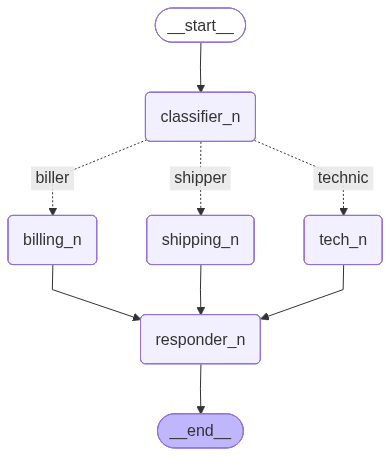

In [10]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# run graph -- shipping
sample_state = SupportTicket(query="I haven't recieved my package yet")

result = graph.invoke(sample_state)

print(result)
print("=="*40)
print(result["nodes_ran"])
print("=="*40)
print(result["response"])
print("=="*40)

{'query': "I haven't recieved my package yet", 'intent': 'shipping', 'data': 'Here is a sample dataset representing customer details similar to the context you provided:\n\n---\n\n### Customer Data Sample\n\n| **Field**                | **Description**                                                                 |\n|--------------------------|-----------------------------------------------------------------------------|\n| **Name**                 | Full name of the customer.                                                                                  |\n| **Email Address**        | Likely email address, e.g., `user@example.com`.                                       |\n| **Phone Number**         | Phone number as a separate line item.                                                   |\n| **Status**              | Status of the order:       | Current, In Transit (Packet Packate), or Expected Delivery |\n| **Expected Delivery Date** | Today or tomorrow.               | Tomorrow 

In [12]:
# run graph -- shipping
sample_state = SupportTicket(query="How to reset this system ?")

result = graph.invoke(sample_state)

print(result)
print("=="*40)
print(result["nodes_ran"])
print("=="*40)
print(result["response"])
print("=="*40)

{'query': 'How to reset this system ?', 'intent': 'the query "how to reset this system?" falls under the category of **technical** because it pertains to instructions on resetting a system, which typically involves configuring or adjusting features related to software or hardware.', 'data': 'Here’s a sample dataset formatted in JSON, structured to simulate common customer troubleshooting outcomes:\n\n```json\n{\n  "restart_app": {\n    "id": 1,\n    "customer_id": "C1",\n    "status": "success"\n  },\n  "clear_cache": {\n    "id": 2,\n    "customer_id": "C2",\n    "status": "success"\n  },\n  "re_login": {\n    "id": 3,\n    "customer_id": "C3",\n    "status": "success"\n  }\n}\n```\n\n### Explanation:\n- **restart_app**: This outcome indicates that the user had to restart the application. The customer ID is "C1" and it resulted in a "success" status.\n- **clear_cache**: This outcome suggests that the user needed to clear their cache. Customer ID is "C2", resulting in a "success".\n- *